# Exploration des donnees - Lean Planning
Analyse du fichier CSV de reservation des salles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Chargement et nettoyage

In [2]:
csv_path = sorted(Path('public/data').glob('*.csv'))[-1]
print(f'Fichier: {csv_path.name}')

df = pd.read_csv(csv_path, sep=';', encoding='utf-8')
df.columns = ['enseignant', 'salle', 'promo', 'matiere', 'date', 'heure', 'duree', 'ecole', 'campus', 'num_cours']

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['heure'] = pd.to_timedelta(df['heure'])
df['jour_semaine'] = df['date'].dt.day_name()
df['semaine'] = df['date'].dt.isocalendar().week.astype(int)
df['mois'] = df['date'].dt.to_period('M')
df['annee_semaine'] = df['date'].dt.strftime('%Y-S%W')

print(f'Reservations: {len(df)}')
print(f'Periode: {df["date"].min().strftime("%d/%m/%Y")} -> {df["date"].max().strftime("%d/%m/%Y")}')
print(f'Salles uniques: {df["salle"].nunique()}')
print(f'Campus: {df["campus"].nunique()}')
df.head()

Fichier: 04022026_1000.csv
Reservations: 3222
Periode: 02/09/2024 -> 30/06/2025
Salles uniques: 137
Campus: 9


,enseignant,salle,promo,matiere,date,heure,duree,ecole,campus,num_cours,jour_semaine,semaine,mois,annee_semaine
0,GULDNER NAJMA,Salle EM314 (Labo Elec / Info) - E1 (F) (40) (...,<Ing2 NVX> Ing2 Nouveaux,Electronique ING2 NX,2024-09-02,0 days 08:30:00,2.0,ECE PREPA,Eiffel 1,3881.08,Monday,36,2024-09,2024-S36
1,GULDNER NAJMA,Salle EM314 (Labo Elec / Info) - E1 (F) (40) (...,<Ing2 NVX> Ing2 Nouveaux,Electronique ING2 NX,2024-09-02,0 days 10:45:00,2.0,ECE PREPA,Eiffel 1,3883.00,Monday,36,2024-09,2024-S36
2,MOKHBER ARASH,Salle EM224 (Labo Elec) - E1 (F) (40) (Meet-up),<CLASSES> Ing2 Gr10,Conception num�rique sur FPGA,2024-09-03,0 days 08:30:00,2.0,ECE PREPA,Eiffel 1,4986.01,Tuesday,36,2024-09,2024-S36
3,MOKHBER ARASH,Salle EM224 (Labo Elec) - E1 (F) (40) (Meet-up),<CLASSES> Ing2 Gr08,Conception num�rique sur FPGA,2024-09-03,0 days 10:45:00,2.0,ECE PREPA,Eiffel 1,4984.03,Tuesday,36,2024-09,2024-S36
4,KHOURY CLAUDE,Salle EM312 (Labo Elec) - E1 (F) (40) (Meet-up),<CLASSES> Ing2 Gr14,Conception num�rique sur FPGA,2024-09-03,0 days 15:15:00,2.0,ECE PREPA,Eiffel 1,3682.01,Tuesday,36,2024-09,2024-S36


## 2. Vue d'ensemble

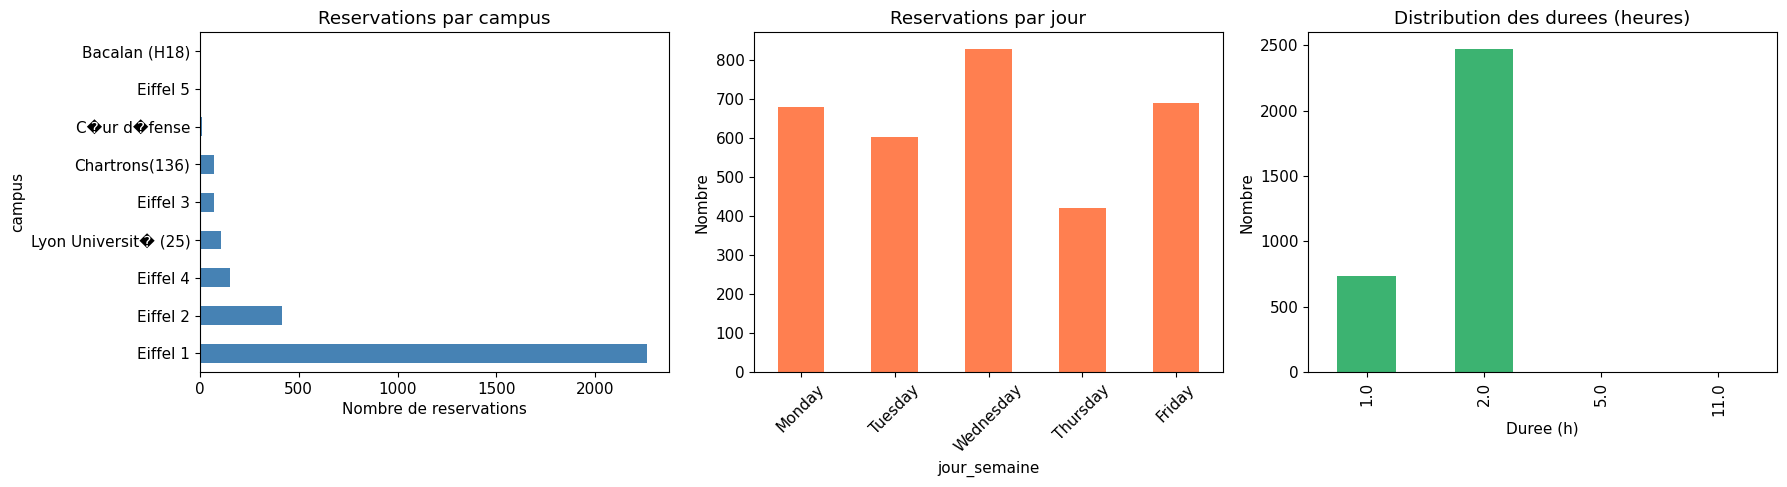

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reservations par campus
df['campus'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Reservations par campus')
axes[0].set_xlabel('Nombre de reservations')

# Reservations par jour de la semaine
jour_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['jour_semaine'].value_counts().reindex(jour_order).dropna().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Reservations par jour')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=45)

# Distribution des durees
df['duree'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribution des durees (heures)')
axes[2].set_xlabel('Duree (h)')
axes[2].set_ylabel('Nombre')

plt.tight_layout()
plt.show()

## 3. Reservations par semaine

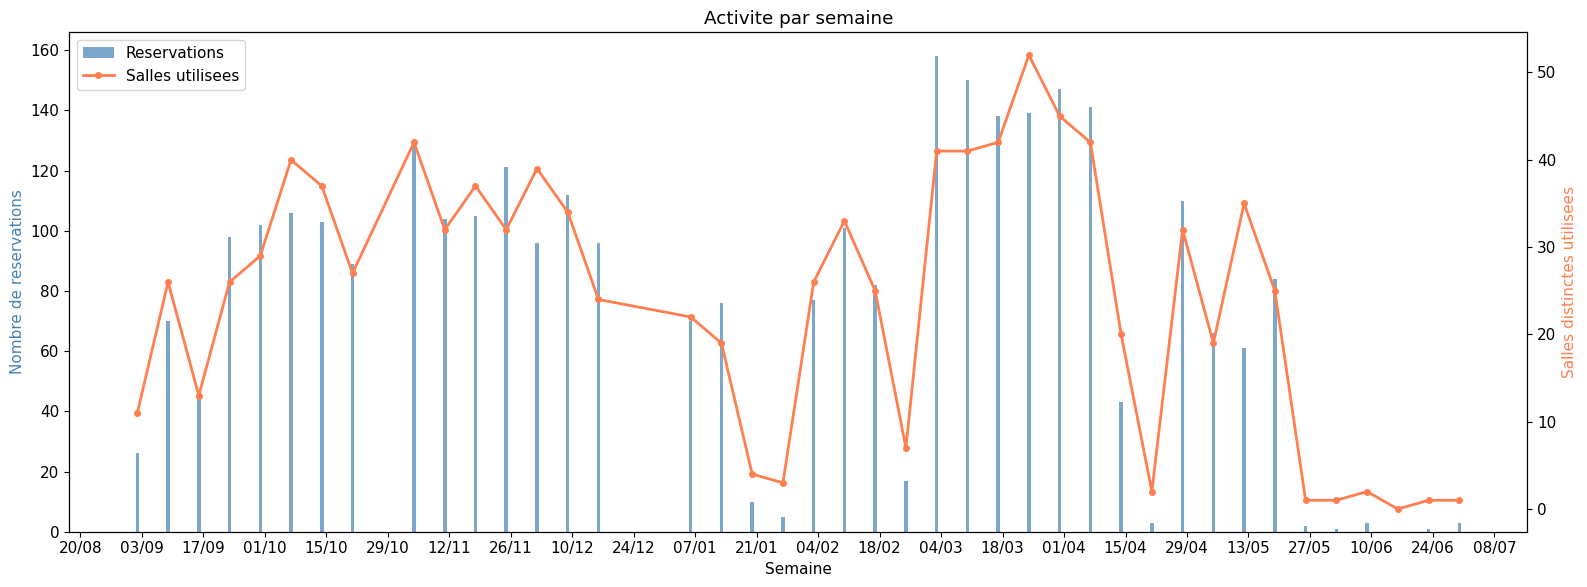

Semaine la plus chargee: 03/03/2025 (158 reservations)
Semaine la moins chargee: 16/06/2025 (0 reservations)
Moyenne: 75 reservations/semaine


In [4]:
# Nombre de reservations par semaine
weekly = df.groupby(df['date'].dt.to_period('W').apply(lambda x: x.start_time)).agg(
    nb_reservations=('salle', 'count'),
    salles_utilisees=('salle', 'nunique'),
    heures_totales=('duree', 'sum')
).reset_index()
weekly.columns = ['semaine', 'nb_reservations', 'salles_utilisees', 'heures_totales']

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.bar(weekly['semaine'], weekly['nb_reservations'], color='steelblue', alpha=0.7, label='Reservations')
ax1.set_xlabel('Semaine')
ax1.set_ylabel('Nombre de reservations', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(weekly['semaine'], weekly['salles_utilisees'], color='coral', linewidth=2, marker='o', markersize=4, label='Salles utilisees')
ax2.set_ylabel('Salles distinctes utilisees', color='coral')

ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Activite par semaine')
plt.tight_layout()
plt.show()

print(f'Semaine la plus chargee: {weekly.loc[weekly["nb_reservations"].idxmax(), "semaine"].strftime("%d/%m/%Y")} ({weekly["nb_reservations"].max()} reservations)')
print(f'Semaine la moins chargee: {weekly.loc[weekly["nb_reservations"].idxmin(), "semaine"].strftime("%d/%m/%Y")} ({weekly["nb_reservations"].min()} reservations)')
print(f'Moyenne: {weekly["nb_reservations"].mean():.0f} reservations/semaine')

## 4. Heures cumulees par semaine

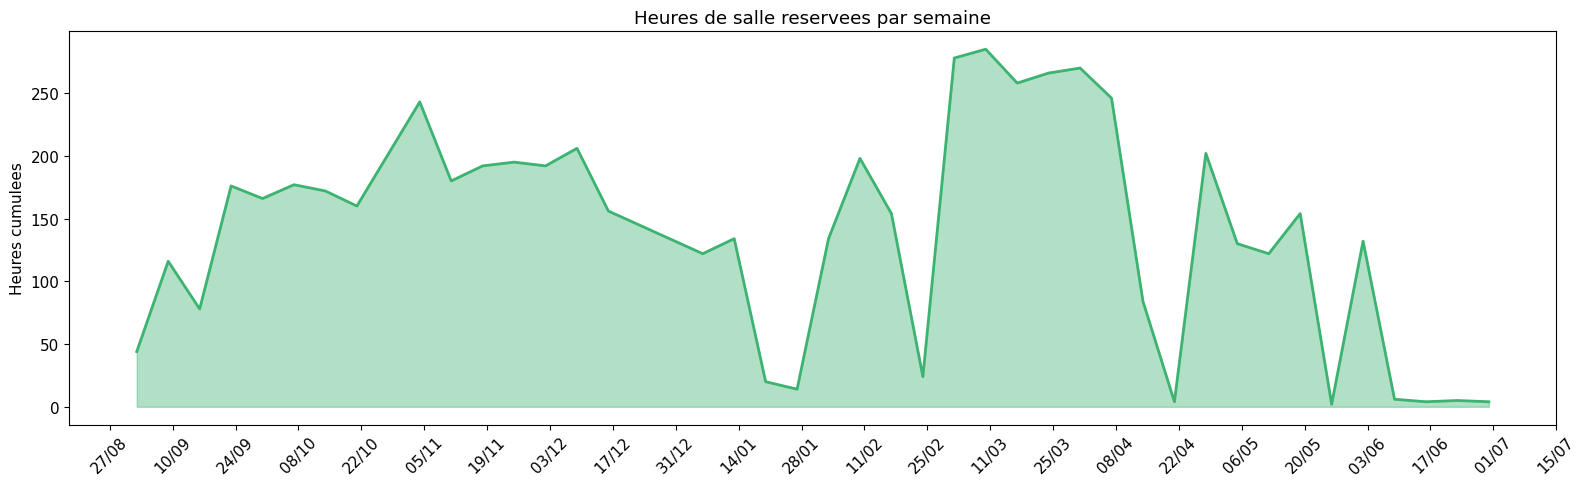

Total heures reservees: 5705h
Moyenne par semaine: 139h


In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(weekly['semaine'], weekly['heures_totales'], color='mediumseagreen', alpha=0.4)
ax.plot(weekly['semaine'], weekly['heures_totales'], color='mediumseagreen', linewidth=2)
ax.set_title('Heures de salle reservees par semaine')
ax.set_ylabel('Heures cumulees')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total heures reservees: {df["duree"].sum():.0f}h')
print(f'Moyenne par semaine: {weekly["heures_totales"].mean():.0f}h')

## 5. Top salles les plus utilisees

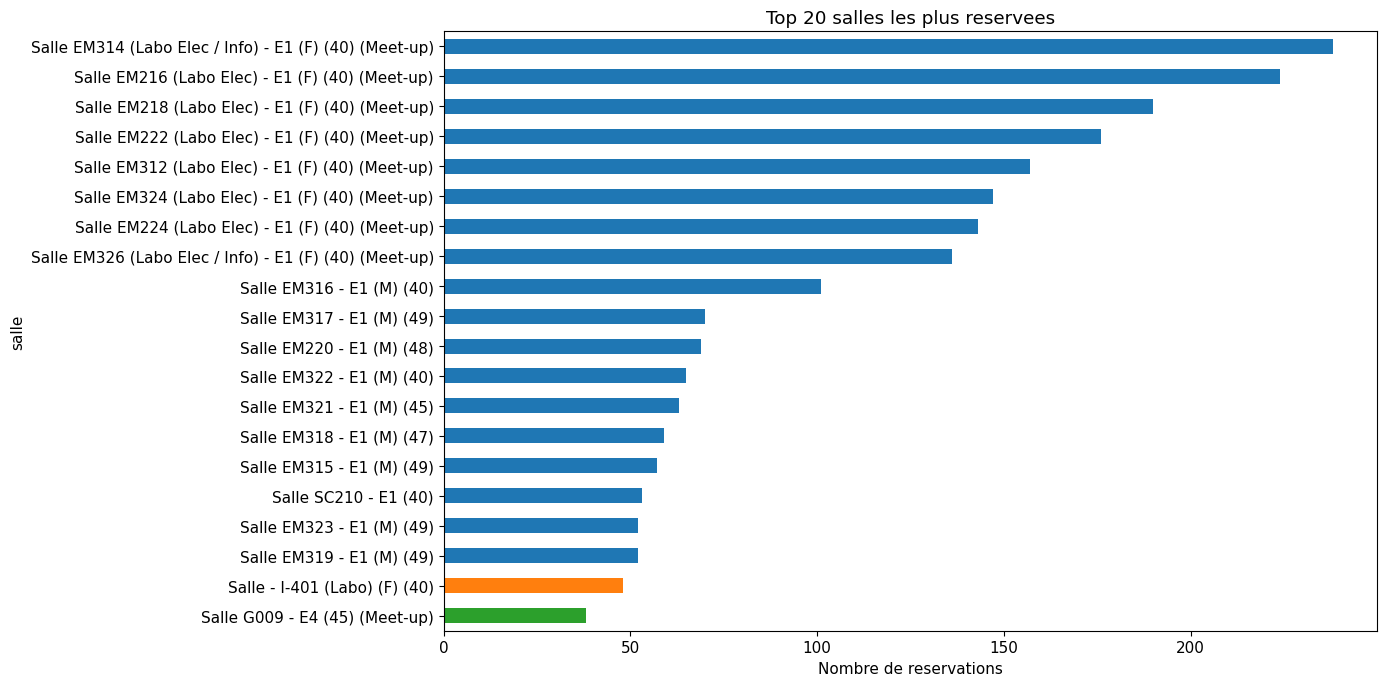

,reservations,heures,campus
salle,,,
Salle EM314 (Labo Elec / Info) - E1 (F) (40) (Meet-up),238,414.0,Eiffel 1
Salle EM216 (Labo Elec) - E1 (F) (40) (Meet-up),224,377.0,Eiffel 1
Salle EM218 (Labo Elec) - E1 (F) (40) (Meet-up),190,332.0,Eiffel 1
Salle EM222 (Labo Elec) - E1 (F) (40) (Meet-up),176,303.0,Eiffel 1
Salle EM312 (Labo Elec) - E1 (F) (40) (Meet-up),157,274.0,Eiffel 1
Salle EM324 (Labo Elec) - E1 (F) (40) (Meet-up),147,256.0,Eiffel 1
Salle EM224 (Labo Elec) - E1 (F) (40) (Meet-up),143,250.0,Eiffel 1
Salle EM326 (Labo Elec / Info) - E1 (F) (40) (Meet-up),136,233.0,Eiffel 1
Salle EM316 - E1 (M) (40),101,171.0,Eiffel 1


In [6]:
top_salles = df.groupby('salle').agg(
    reservations=('date', 'count'),
    heures=('duree', 'sum'),
    campus=('campus', 'first')
).sort_values('reservations', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10([top_salles['campus'].factorize()[0][i] % 10 for i in range(len(top_salles))])
top_salles['reservations'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 salles les plus reservees')
ax.set_xlabel('Nombre de reservations')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_salles[['reservations', 'heures', 'campus']]

## 6. Taux d'occupation par creneau horaire

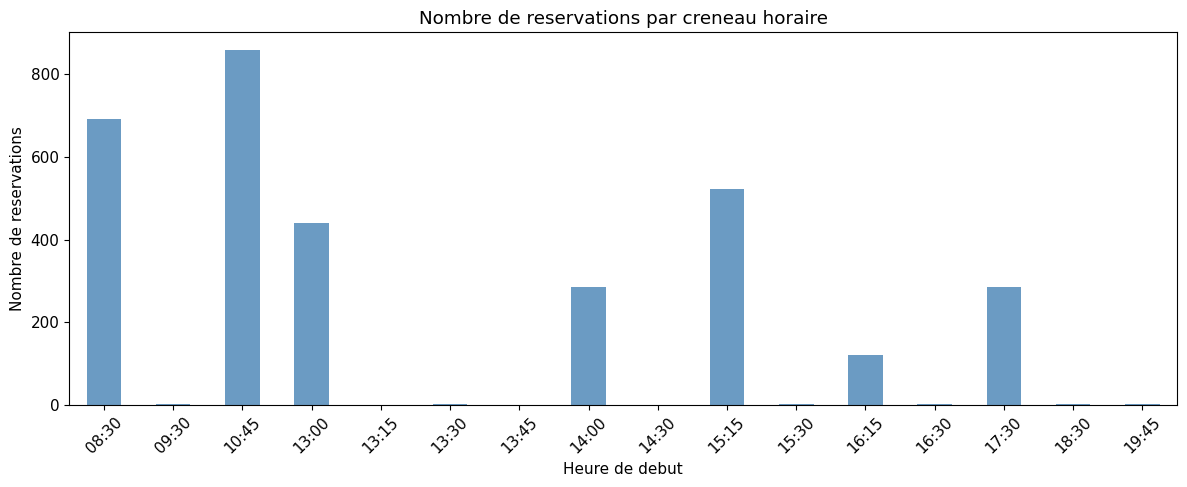

Creneau le plus charge: 10:45 (858 reservations)
Creneau le moins charge: 13:15 (1 reservations)


In [7]:
df['heure_debut'] = df['heure'].apply(lambda x: f'{int(x.total_seconds()//3600):02d}:{int((x.total_seconds()%3600)//60):02d}')

creneaux = df.groupby('heure_debut').size().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
creneaux.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Nombre de reservations par creneau horaire')
ax.set_xlabel('Heure de debut')
ax.set_ylabel('Nombre de reservations')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Creneau le plus charge: {creneaux.idxmax()} ({creneaux.max()} reservations)')
print(f'Creneau le moins charge: {creneaux.idxmin()} ({creneaux.min()} reservations)')

## 7. Heatmap : jour x creneau

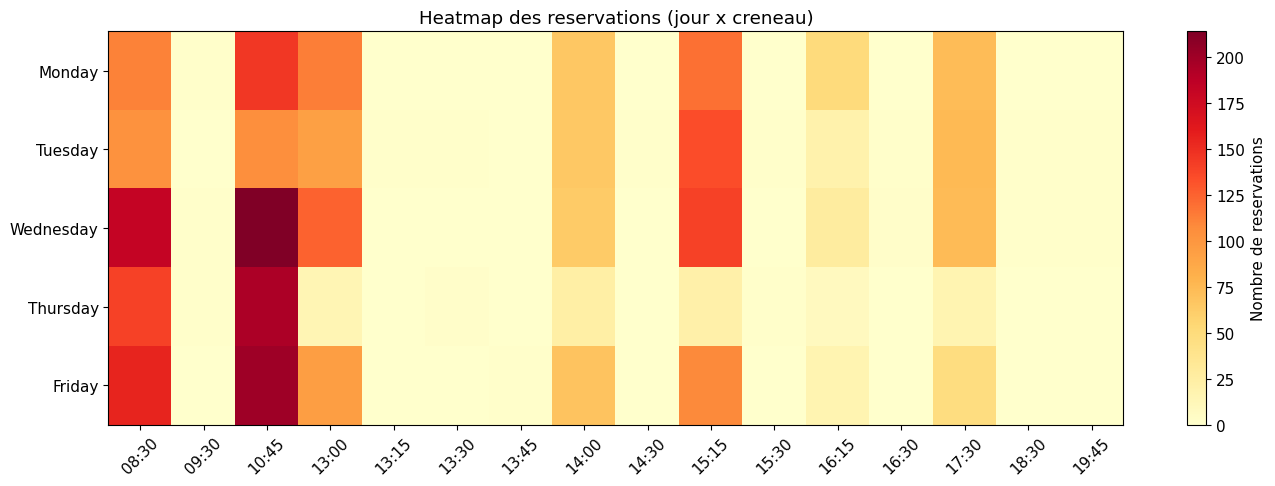

In [8]:
jour_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
heatmap_data = df.groupby(['jour_semaine', 'heure_debut']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(jour_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Heatmap des reservations (jour x creneau)')
plt.colorbar(im, label='Nombre de reservations')
plt.tight_layout()
plt.show()

## 8. Occupation par campus

In [9]:
campus_stats = df.groupby('campus').agg(
    reservations=('date', 'count'),
    salles=('salle', 'nunique'),
    heures=('duree', 'sum'),
    enseignants=('enseignant', 'nunique'),
    matieres=('matiere', 'nunique')
).sort_values('reservations', ascending=False)

campus_stats['heures_par_salle'] = (campus_stats['heures'] / campus_stats['salles']).round(1)

campus_stats

,reservations,salles,heures,enseignants,matieres,heures_par_salle
campus,,,,,,
Eiffel 1,2260,44,3942.0,64,46,89.6
Eiffel 2,414,31,758.0,38,18,24.5
Eiffel 4,154,7,260.0,27,17,37.1
Lyon Universit� (25),107,26,214.0,5,7,8.2
Chartrons(136),70,10,140.0,6,5,14.0
Eiffel 3,70,10,118.0,18,9,11.8
C�ur d�fense,8,6,14.0,4,4,2.3
Eiffel 5,5,2,6.0,3,3,3.0
Bacalan (H18),1,1,2.0,1,1,2.0


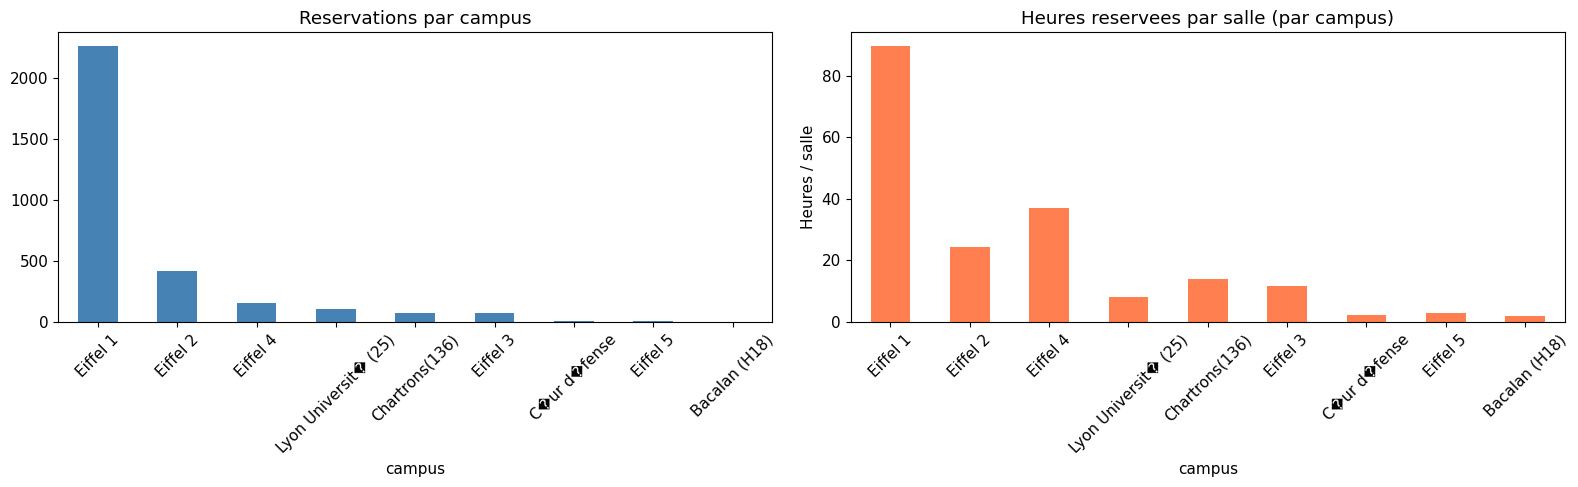

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

campus_stats['reservations'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Reservations par campus')
axes[0].tick_params(axis='x', rotation=45)

campus_stats['heures_par_salle'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Heures reservees par salle (par campus)')
axes[1].set_ylabel('Heures / salle')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Salles jamais utilisees certaines semaines

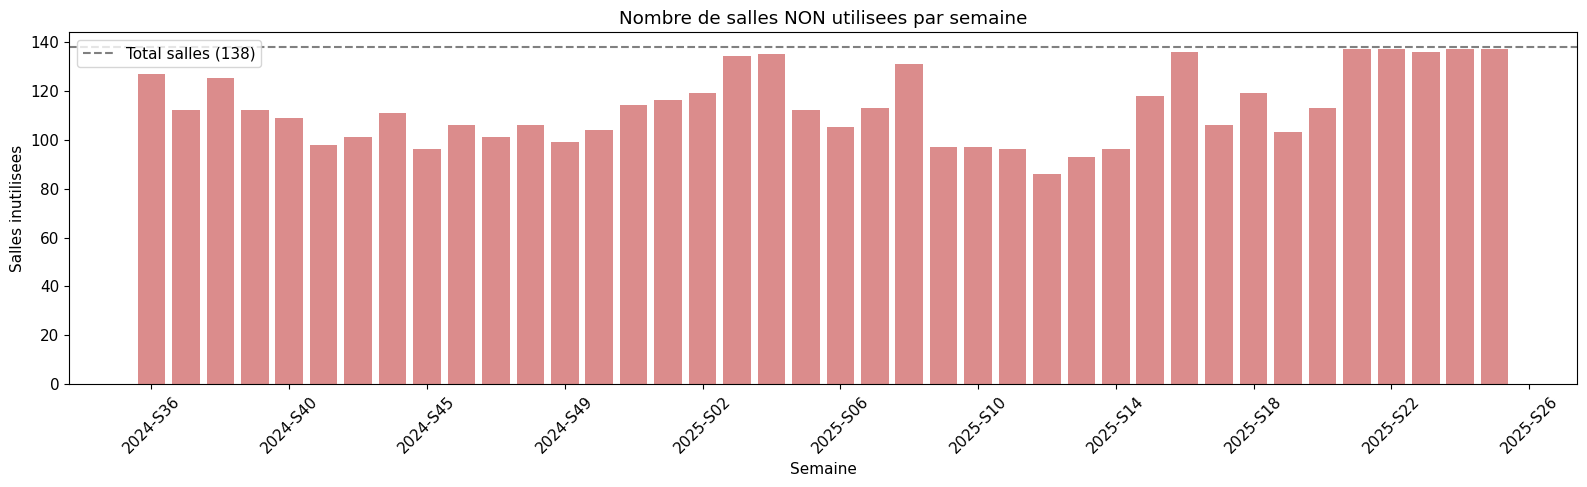

En moyenne 113 salles inutilisees par semaine sur 138
Taux d'utilisation moyen: 17.9%


In [11]:
all_rooms = df['salle'].unique()
weeks = sorted(df['annee_semaine'].unique())

usage_matrix = df.groupby(['annee_semaine', 'salle']).size().unstack(fill_value=0)
usage_matrix = usage_matrix.reindex(columns=all_rooms, fill_value=0)

unused_per_week = (usage_matrix == 0).sum(axis=1)
total_rooms = len(all_rooms)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(unused_per_week)), unused_per_week.values, color='indianred', alpha=0.7)
ax.axhline(y=total_rooms, color='gray', linestyle='--', label=f'Total salles ({total_rooms})')
ax.set_title('Nombre de salles NON utilisees par semaine')
ax.set_xlabel('Semaine')
ax.set_ylabel('Salles inutilisees')
ax.set_xticks(range(0, len(weeks), 4))
ax.set_xticklabels([weeks[i] for i in range(0, len(weeks), 4)], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(f'En moyenne {unused_per_week.mean():.0f} salles inutilisees par semaine sur {total_rooms}')
print(f'Taux d\'utilisation moyen: {((total_rooms - unused_per_week.mean()) / total_rooms * 100):.1f}%')

## 10. Resume chiffres cles

In [12]:
print('=' * 50)
print('       RESUME - LEAN PLANNING')
print('=' * 50)
print(f'Periode           : {df["date"].min().strftime("%d/%m/%Y")} -> {df["date"].max().strftime("%d/%m/%Y")}')
print(f'Reservations      : {len(df)}')
print(f'Salles uniques    : {df["salle"].nunique()}')
print(f'Campus            : {df["campus"].nunique()}')
print(f'Enseignants       : {df["enseignant"].nunique()}')
print(f'Matieres          : {df["matiere"].nunique()}')
print(f'Heures reservees  : {df["duree"].sum():.0f}h')
print(f'Moy/semaine       : {weekly["nb_reservations"].mean():.0f} reservations')
print(f'Moy heures/sem    : {weekly["heures_totales"].mean():.0f}h')
print('=' * 50)

       RESUME - LEAN PLANNING
Periode           : 02/09/2024 -> 30/06/2025
Reservations      : 3222
Salles uniques    : 137
Campus            : 9
Enseignants       : 83
Matieres          : 56
Heures reservees  : 5705h
Moy/semaine       : 75 reservations
Moy heures/sem    : 139h
